# Fake Product Review Detection
## Part 2 — Feature Engineering & Model Comparison

This notebook covers:
1. Loading the preprocessed dataset from Part 1
2. Feature engineering (BoW + TF-IDF)
3. Training and evaluating 6 classifiers
4. Comparing model accuracy

In [1]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings, string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')

## 1. Load Preprocessed Dataset

In [ ]:
df = pd.read_csv('Data Sets/Preprocessed_Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (40432, 4)


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,love well made sturdy comfortable love pretty
1,Home_and_Kitchen_5,5.0,CG,love great upgrade original mine couple year
2,Home_and_Kitchen_5,5.0,CG,pillow saved back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,missing information use great product price
4,Home_and_Kitchen_5,5.0,CG,nice set good quality set two month


In [3]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40431 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40431 non-null  object 
 1   rating    40431 non-null  float64
 2   label     40431 non-null  object 
 3   text_     40431 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.5+ MB


## 2. Review Length Analysis

In [4]:
df['length'] = df['text_'].apply(len)
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20215.0,162.354242,163.857588,4.0,54.00,93.0,202.0,1246.0
OR,20216.0,236.619064,254.028478,8.0,72.75,132.0,293.0,2048.0


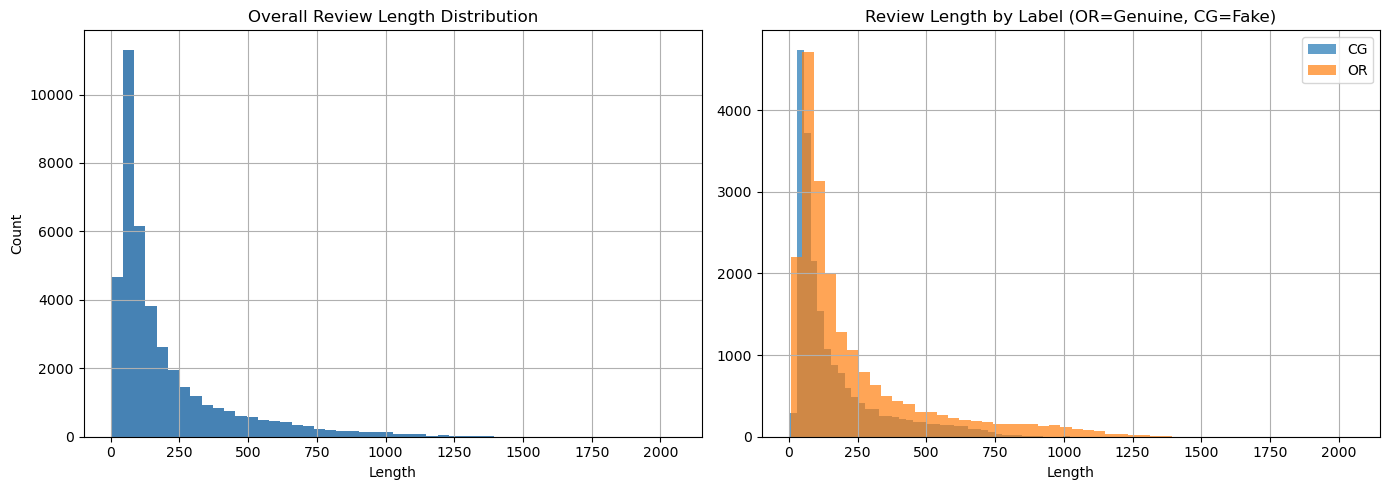

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['length'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Overall Review Length Distribution')
axes[0].set_xlabel('Length'); axes[0].set_ylabel('Count')

for label, grp in df.groupby('label'):
    grp['length'].hist(bins=50, alpha=0.7, ax=axes[1], label=label)
axes[1].set_title('Review Length by Label (OR=Genuine, CG=Fake)')
axes[1].set_xlabel('Length'); axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
# Longest genuine review (OR = Original)
df[df['label'] == 'OR'][['text_', 'length']].sort_values(by='length', ascending=False).head(1).iloc[0].text_

'weak current science seeing twice agree much positive five star review respect read review repeat everything like presentation found goofy oversize earring hairdo facial hair arrangement daniel vitalis described wild food expert distracting ugh ditto david wolfe extremely goofy wild hairdo hand jon gabriel described author weight loss expert nicely groomed good presenter story personal transformation fellow pound whew becoming jock normal weight inspiring christiane northrup preserve rank one america cutest doctor really nice looking woman presentation dr mercola jason vale kris carr alejandro junger fine disappointing jamie oliver popular uk give baby cow growth fluid pas unscientific popular idea milk none presenter anything zilch say work doctor colin campbell milk body bad good see presenter take stand sugar agreed evil sugar refined carbohydrate respect dr northrup fat make fat sugar statement pas muster community expert recognizing evil sugar mutually exclusive recognizing prove

In [7]:
print('Review length stats:')
print(df['length'].describe())

Review length stats:
count    40431.000000
mean       199.487571
std        216.951779
min          4.000000
25%         61.000000
50%        111.000000
75%        245.000000
max       2048.000000
Name: length, dtype: float64


## 3. Feature Engineering — Bag of Words & TF-IDF

The text is already preprocessed (stopwords removed, lemmatized). We use a simple `text_process` analyzer that handles any residual punctuation before vectorisation.

In [8]:
def text_process(review):
    """Light cleanup: strip residual punctuation before tokenising."""
    nopunc = [char for char in str(review) if char not in string.punctuation]
    return ''.join(nopunc).split()

# Bag-of-Words transformer
bow_transformer = CountVectorizer(analyzer=text_process)
bow_transformer.fit(df['text_'])
print('Total Vocabulary:', len(bow_transformer.vocabulary_))

Total Vocabulary: 35900


In [9]:
# Inspect a sample review
review4 = df['text_'].iloc[3]
print('Review:', review4)
bow_msg4 = bow_transformer.transform([review4])
print('BoW shape:', bow_msg4.shape, '| Non-zero entries:', bow_msg4.nnz)

Review: missing information use great product price
BoW shape: (1, 35900) | Non-zero entries: 6


In [10]:
# Lookup two example words in the vocabulary — safe dictionary lookup
for word in ['love', 'book']:
    if word in bow_transformer.vocabulary_:
        idx = bow_transformer.vocabulary_[word]
        print(f"Word: '{word}' → vocab index: {idx}")
    else:
        print(f"Word: '{word}' not in vocabulary")

Word: 'love' → vocab index: 19165
Word: 'book' → vocab index: 4560


In [11]:
bow_reviews = bow_transformer.transform(df['text_'])
print('BoW matrix shape:', bow_reviews.shape)
print('Non-zero values  :', bow_reviews.nnz)
print('Sparsity (%)     :', np.round(bow_reviews.nnz / (bow_reviews.shape[0] * bow_reviews.shape[1]) * 100, 4))

BoW matrix shape: (40431, 35900)
Non-zero values  : 1006313
Sparsity (%)     : 0.0693


In [12]:
# TF-IDF transformation
tfidf_transformer = TfidfTransformer().fit(bow_reviews)
tfidf_rev4 = tfidf_transformer.transform(bow_msg4)
print('TF-IDF vector for review 4:')
print(tfidf_rev4)

# IDF scores for two reference words
for word in ['love', 'book']:
    if word in bow_transformer.vocabulary_:
        idf = tfidf_transformer.idf_[bow_transformer.vocabulary_[word]]
        print(f"IDF('{word}') = {idf:.4f}")

TF-IDF vector for review 4:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (1, 35900)>
  Coords	Values
  (0, 14254)	0.20937706409252027
  (0, 16479)	0.5509113459826932
  (0, 20700)	0.5963657383518689
  (0, 24649)	0.33324215870428314
  (0, 24777)	0.31240501907259
  (0, 33821)	0.2972517581780275
IDF('love') = 2.4009
IDF('book') = 2.8195


In [13]:
tfidf_reviews = tfidf_transformer.transform(bow_reviews)
print('TF-IDF matrix shape:', tfidf_reviews.shape)
print('Dimensions        :', tfidf_reviews.ndim)

TF-IDF matrix shape: (40431, 35900)
Dimensions        : 2


## 4. Train / Test Split

`random_state=42` ensures reproducible splits across runs.

In [14]:
review_train, review_test, label_train, label_test = train_test_split(
    df['text_'], df['label'],
    test_size=0.35,
    random_state=42     # fixed for reproducibility
)
print('Train size:', len(review_train), '| Test size:', len(review_test))

Train size: 26280 | Test size: 14151


## 5. Model Training & Evaluation

A `Pipeline` chains BoW → TF-IDF → classifier, keeping preprocessing consistent across train and test.

In [15]:
def evaluate_model(name, pipeline, review_train, review_test, label_train, label_test):
    """Fit pipeline and print metrics."""
    pipeline.fit(review_train, label_train)
    preds = pipeline.predict(review_test)
    acc = np.round(accuracy_score(label_test, preds) * 100, 2)
    print(f'\n{'='*55}')
    print(f'{name} — Accuracy: {acc}%')
    print(f'{'='*55}')
    print(classification_report(label_test, preds))
    print('Confusion Matrix:')
    print(confusion_matrix(label_test, preds))
    return acc, preds

### 5.1 Multinomial Naive Bayes

In [16]:
nb_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])
nb_acc, nb_pred = evaluate_model('Multinomial Naive Bayes', nb_pipeline,
                                  review_train, review_test, label_train, label_test)


Multinomial Naive Bayes — Accuracy: 84.06%
              precision    recall  f1-score   support

          CG       0.80      0.90      0.85      7104
          OR       0.89      0.78      0.83      7047

    accuracy                           0.84     14151
   macro avg       0.85      0.84      0.84     14151
weighted avg       0.85      0.84      0.84     14151

Confusion Matrix:
[[6423  681]
 [1574 5473]]


### 5.2 Random Forest Classifier

In [17]:
rf_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_acc, rf_pred = evaluate_model('Random Forest', rf_pipeline,
                                  review_train, review_test, label_train, label_test)


Random Forest — Accuracy: 84.88%
              precision    recall  f1-score   support

          CG       0.82      0.89      0.86      7104
          OR       0.88      0.81      0.84      7047

    accuracy                           0.85     14151
   macro avg       0.85      0.85      0.85     14151
weighted avg       0.85      0.85      0.85     14151

Confusion Matrix:
[[6332  772]
 [1367 5680]]


### 5.3 Decision Tree Classifier

In [18]:
dt_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
dt_acc, dt_pred = evaluate_model('Decision Tree', dt_pipeline,
                                  review_train, review_test, label_train, label_test)


Decision Tree — Accuracy: 75.22%
              precision    recall  f1-score   support

          CG       0.75      0.76      0.76      7104
          OR       0.76      0.74      0.75      7047

    accuracy                           0.75     14151
   macro avg       0.75      0.75      0.75     14151
weighted avg       0.75      0.75      0.75     14151

Confusion Matrix:
[[5405 1699]
 [1808 5239]]


### 5.4 K-Nearest Neighbors

`n_neighbors=5` (odd number) avoids tie-breaking issues in binary classification.

In [19]:
knn_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))  # 5 instead of 2 (odd avoids ties)
])
knn_acc, knn_pred = evaluate_model('K-Nearest Neighbors (k=5)', knn_pipeline,
                                     review_train, review_test, label_train, label_test)


K-Nearest Neighbors (k=5) — Accuracy: 61.75%
              precision    recall  f1-score   support

          CG       0.57      0.95      0.71      7104
          OR       0.85      0.28      0.42      7047

    accuracy                           0.62     14151
   macro avg       0.71      0.62      0.57     14151
weighted avg       0.71      0.62      0.57     14151

Confusion Matrix:
[[6755  349]
 [5064 1983]]


### 5.5 Support Vector Machine

In [ ]:
svm_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', SVC())
])
svm_acc, svm_pred = evaluate_model('Support Vector Machine', svm_pipeline,
                                    review_train, review_test, label_train, label_test)

In [20]:
# 1. Update the pipeline to use LinearSVC and standard tokenization
svm_pipeline = Pipeline([
    ('bow', CountVectorizer()), # Drops analyzer if text is already preprocessed
    ('tfidf', TfidfTransformer()),
    ('classifier', LinearSVC(dual=False)) # Massive speedup for text classification
])

# 2. Evaluate again (this should finish in under 30 seconds)
svm_acc, svm_pred = evaluate_model('Support Vector Machine', svm_pipeline,
                                   review_train, review_test, label_train, label_test)


Support Vector Machine — Accuracy: 87.27%
              precision    recall  f1-score   support

          CG       0.88      0.87      0.87      7104
          OR       0.87      0.88      0.87      7047

    accuracy                           0.87     14151
   macro avg       0.87      0.87      0.87     14151
weighted avg       0.87      0.87      0.87     14151

Confusion Matrix:
[[6181  923]
 [ 878 6169]]


### 5.6 Logistic Regression

In [21]:
lr_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', LogisticRegression(max_iter=1000))
])
lr_acc, lr_pred = evaluate_model('Logistic Regression', lr_pipeline,
                                  review_train, review_test, label_train, label_test)


Logistic Regression — Accuracy: 86.67%
              precision    recall  f1-score   support

          CG       0.88      0.84      0.86      7104
          OR       0.85      0.89      0.87      7047

    accuracy                           0.87     14151
   macro avg       0.87      0.87      0.87     14151
weighted avg       0.87      0.87      0.87     14151

Confusion Matrix:
[[5998 1106]
 [ 781 6266]]


## 6. Conclusion — Model Comparison

In [22]:
results = {
    'Logistic Regression':      lr_acc,
    'Support Vector Machine':   svm_acc,
    'Random Forest':            rf_acc,
    'Decision Tree':            dt_acc,
    'Multinomial Naive Bayes':  nb_acc,
    'K-Nearest Neighbors (k=5)': knn_acc,
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy (%)'])
results_df = results_df.sort_values('Accuracy (%)', ascending=False)
print('Performance of all ML models:')
print(results_df.to_string())

Performance of all ML models:
                           Accuracy (%)
Support Vector Machine            87.27
Logistic Regression               86.67
Random Forest                     84.88
Multinomial Naive Bayes           84.06
Decision Tree                     75.22
K-Nearest Neighbors (k=5)         61.75


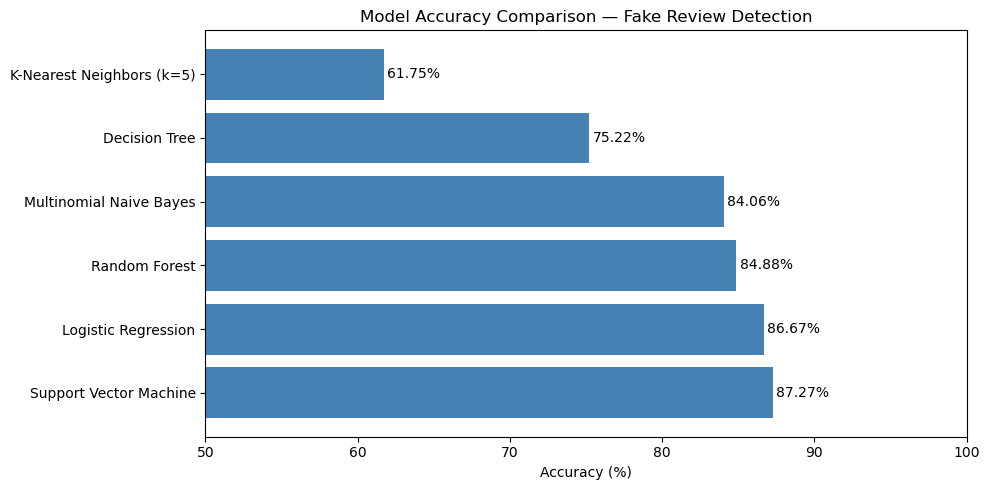

In [23]:
# Visual comparison
plt.figure(figsize=(10, 5))
plt.barh(results_df.index, results_df['Accuracy (%)'], color='steelblue')
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison — Fake Review Detection')
plt.xlim(50, 100)
for i, v in enumerate(results_df['Accuracy (%)']):
    plt.text(v + 0.2, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()